<a href="https://colab.research.google.com/github/juanrizo22/eye_disease_classification/blob/main/model%202/juanes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub

# Download latest version
base_path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")

print("Path to dataset files:", base_path)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [11]:

import os

for clase in os.listdir(base_path):
    n = len(os.listdir(os.path.join(base_path, clase)))
    print(f"{clase}: {n} imágenes")

dataset: 4 imágenes


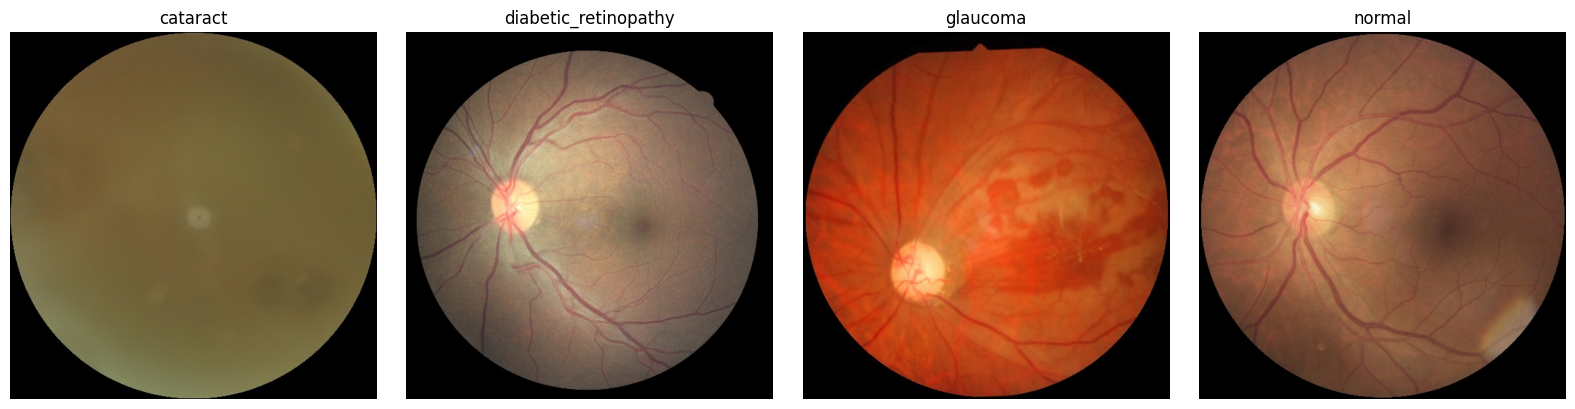

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os # Ensure os is imported as it's used later

# Define the path to the actual image data
data_root = os.path.join(base_path, 'dataset')

# Get the list of class directories (e.g., 'glaucoma', 'normal')
class_names = [d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))]
class_names.sort() # Optional: sort for consistent display

num_classes = len(class_names)
fig, axs = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4)) # Dynamic subplot sizing

# Handle the case where there's only one class to ensure axs is always iterable
if num_classes == 1:
    axs = [axs]

for i, clase in enumerate(class_names):
    class_folder = os.path.join(data_root, clase)

    # List all files in the class folder and filter for image files
    image_files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if image_files:
        # Take the first image file found in the folder
        first_image_file = sorted(image_files)[0] # Sort to get a consistent 'first' image
        img_path = os.path.join(class_folder, first_image_file)
        img = Image.open(img_path)

        axs[i].imshow(img)
        axs[i].set_title(clase)
        axs[i].axis('off')
    else:
        print(f"Warning: No image files found in class folder: {class_folder}")

plt.tight_layout() # Adjust layout to prevent titles from overlapping
plt.show()

In [10]:
import hashlib
import os # Ensure os is imported here as well

def hash_imagen(ruta):
    # Check if the path is actually a file before attempting to open it
    if os.path.isfile(ruta):
        with open(ruta, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    return None # Return None or raise an error if it's not a file

hashes = {}
duplicados = []

# Define the path to the actual image data, similar to the previous cell
data_root = os.path.join(base_path, 'dataset')

# Get the list of class directories
class_names = [d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))]

for clase in class_names:
    class_folder = os.path.join(data_root, clase)

    # Iterate through files within each class folder
    for archivo in os.listdir(class_folder):
        ruta = os.path.join(class_folder, archivo)

        # Only process actual files (to avoid hashing subdirectories if any exist)
        if os.path.isfile(ruta):
            h = hash_imagen(ruta)
            if h:
                if h in hashes:
                    duplicados.append((ruta, hashes[h]))
                else:
                    hashes[h] = ruta

print(f"Duplicados encontrados: {len(duplicados)}")

Duplicados encontrados: 2
